In [2]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.05 ):
            control_[:,:,i_time] = maxI_
    return control_

In [4]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 0.1
    aln.params.sigmai_ext = 0.1
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    """
    aln.params.Jee_max = 1e-26
    aln.params.cee = 0.
    #aln.params.Jei_max = 1.
    #aln.params.cei = 0.5
    aln.params.Jie_max = 1e-26
    aln.params.cie = 0.
    aln.params.Jii_max = 1e-26
    aln.params.cii = 0.

    # Coupling strengths used in Cakan2020
    params.Jee_max = 2.43  # mV/ms
    params.Jie_max = 2.60  # mV/ms
    params.Jei_max = -3.3  # mV/ms [0-(-10)]
    params.Jii_max = -1.64  # mV/ms
    """
    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.


In [5]:
rates_exc_init = np.array( [[15. ]] )
rates_inh_init = np.array( [[15. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

In [13]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-20

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [74]:
def plot_fig(i):
    lines = 8
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    axes[0,i].plot(aln.t, control1[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control1[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    
    
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")
    

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_dif(diff_):
    fig, axes = plt.subplots(1,2, figsize=(18, 3))
    axes[0].plot(aln.t, diff_[0,:], label="difference in exc rate")
    axes[1].plot(aln.t, diff_[1,:], label="difference in inh rate")

    for j in range(2):
        axes[j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

max delay =  0


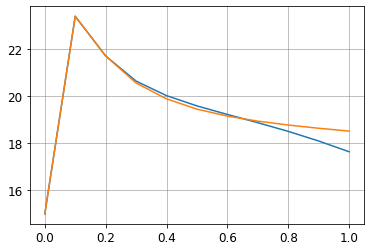

In [17]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

[15.         23.39774207 21.71526918 20.63956298 19.75105913 19.1600824
 18.59909265 18.09183447 17.77720687 17.45996797 17.11700908]
[15.         23.39774207 23.39774207 22.094111   14.11423673 13.80991654
 16.51006914 16.24052677 16.13057334 16.07213837 16.0366818 ]


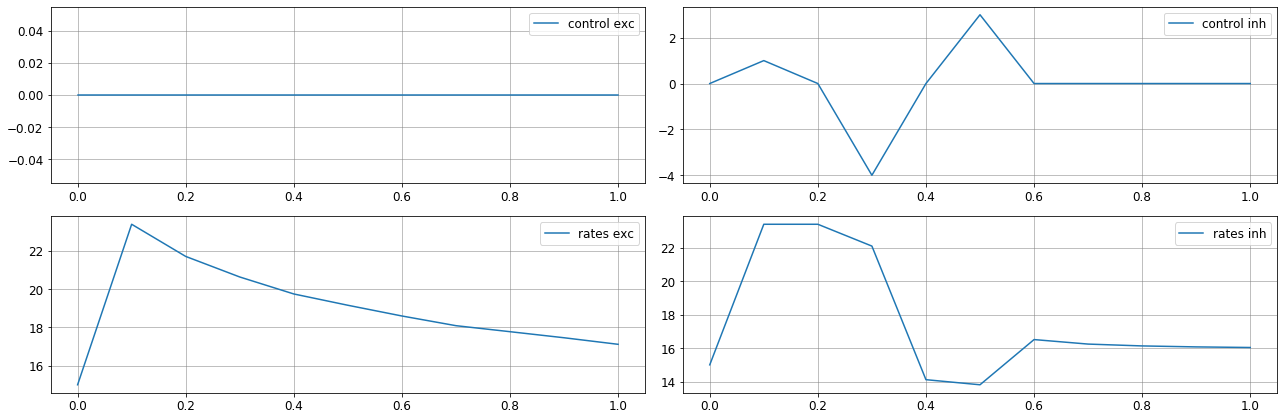

In [28]:
#setparams()

dur = 1.
aln.params.duration = dur
aln.params.di = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

#control1[0,0,1] += 100.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

control1 = aln.getZeroControl()
control1[0,1,3] -= 4.
control1[0,1,1] += 1.
control1[0,1,5] += 3.
#control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0)
plt.savefig("inh_control_no_delay.pdf")
rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[15.         23.39774207 21.7303759  20.65616001 19.78260342 19.22568465
 18.85213012 18.70616748 18.3317368  17.86979847 17.52783205]
[15.         23.39774207 23.39782965 22.10401038 14.19412545 13.89598027
 16.75094024 16.63516326 16.49078153 16.38551521 16.3535304 ]


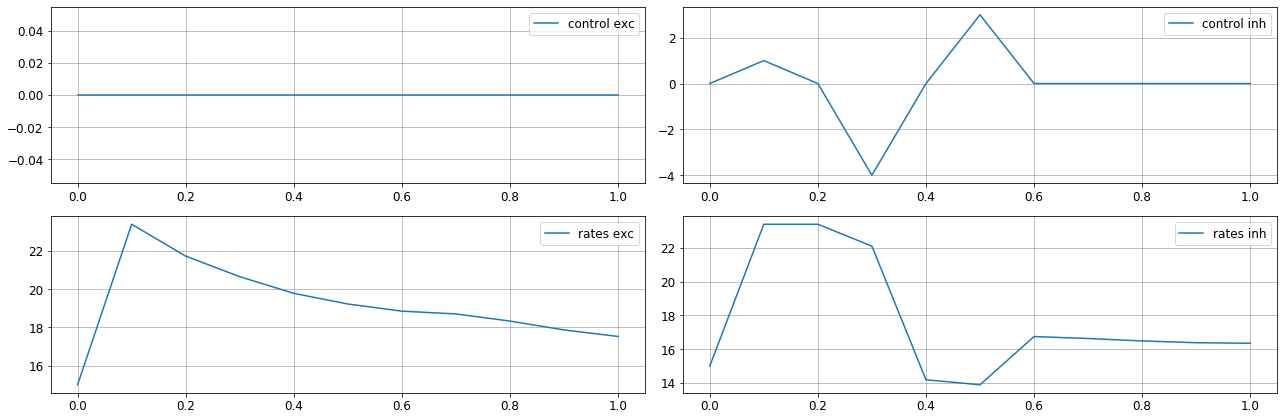

In [111]:
aln.params.di = 0.2
aln.run(control=control1)

rates2 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0)
plt.savefig("inh_control_delay.pdf")
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

(2, 11)
[ 0.          0.         -0.01510672 -0.01659703 -0.03154429 -0.06560225
 -0.25303747 -0.614333   -0.55452993 -0.4098305  -0.41082297]


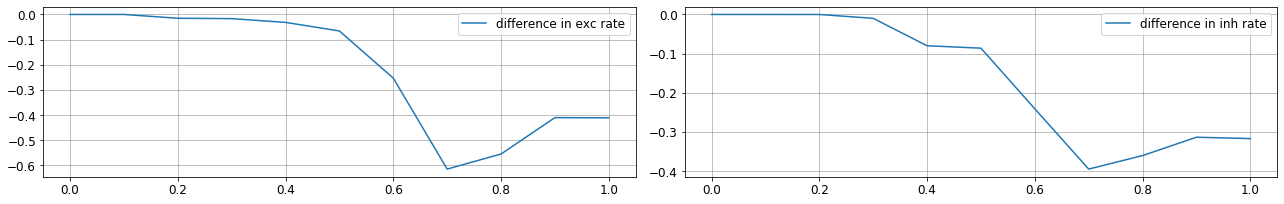

In [112]:
diff = rates1 - rates2
print(diff.shape)
plot_dif(diff)
plt.savefig("diff.pdf")
print(diff[0,:])

In [29]:
max_cntrl = 50. * 5.
start_step = 100.
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
#control2 = control1
#control2[0,1,:] += 0.1
#control2[0,1,7] += 0.1

max_it = 500
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [0])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control


set cost params
True 2
RUN  0 , total integrated cost =  0.005471092273783921
RUN  1 , total integrated cost =  0.0012278873565022518
RUN  2 , total integrated cost =  0.001213290237291948
RUN  3 , total integrated cost =  0.0011991143695575723
RUN  4 , total integrated cost =  0.0011845405030148437
RUN  5 , total integrated cost =  0.001171515861969474
RUN  6 , total integrated cost =  0.0011587029455455305
RUN  7 , total integrated cost =  0.001146597181295609
RUN  8 , total integrated cost =  0.001134425765299878
RUN  9 , total integrated cost =  0.0011204231774264914
RUN  10 , total integrated cost =  0.001106201230867473
RUN  11 , total integrated cost =  0.0010920687136364367
RUN  12 , total integrated cost =  0.001078816801036313
RUN  13 , total integrated cost =  0.0010643259489729851
RUN  14 , total integrated cost =  0.001050329937478645
RUN  15 , total integrated cost =  0.0010372364552704977
RUN  16 , total integrated cost =  0.001024560009882138
RUN  17 , total integrated 

RUN  26 , total integrated cost =  0.000897917199162235
RUN  27 , total integrated cost =  0.0008858225254763585
RUN  28 , total integrated cost =  0.0008744260712196068
RUN  29 , total integrated cost =  0.0008619955930573506
RUN  30 , total integrated cost =  0.0008500763365247012
RUN  31 , total integrated cost =  0.0008387495269325999
RUN  32 , total integrated cost =  0.0008279675413731548
RUN  33 , total integrated cost =  0.0008159923246499863
RUN  34 , total integrated cost =  0.0008035746866106602
RUN  35 , total integrated cost =  0.0007872611452137273
RUN  36 , total integrated cost =  0.0007711053278917595
RUN  37 , total integrated cost =  0.000758946317638584
RUN  38 , total integrated cost =  0.00074713870893569
RUN  39 , total integrated cost =  0.0007351742822634768
RUN  40 , total integrated cost =  0.000722962041158107
RUN  41 , total integrated cost =  0.0007123425452247535
RUN  42 , total integrated cost =  0.0007022326415726519
RUN  43 , total integrated cost =  0

RUN  62 , total integrated cost =  0.0005268232888388578
RUN  63 , total integrated cost =  0.0005196295425942731
RUN  64 , total integrated cost =  0.0005129709030180806
RUN  65 , total integrated cost =  0.000506210704114171
RUN  66 , total integrated cost =  0.0004994981961916206
RUN  67 , total integrated cost =  0.0004930954760121318
RUN  68 , total integrated cost =  0.0004863906625894622
RUN  69 , total integrated cost =  0.0004802404788373035
RUN  70 , total integrated cost =  0.00047444278645816345
RUN  71 , total integrated cost =  0.0004676046506611406
RUN  72 , total integrated cost =  0.0004612086925896012
RUN  73 , total integrated cost =  0.00045522647624667906
RUN  74 , total integrated cost =  0.00044904014778384196
RUN  75 , total integrated cost =  0.0004424400540483677
RUN  76 , total integrated cost =  0.0004363231413164338
RUN  77 , total integrated cost =  0.0004304338819562849
RUN  78 , total integrated cost =  0.0004245884588146983
RUN  79 , total integrated co

RUN  96 , total integrated cost =  0.0003277561811229946
RUN  97 , total integrated cost =  0.0003201776809099286
RUN  98 , total integrated cost =  0.0003122712356594451
RUN  99 , total integrated cost =  0.00030593430709210733
RUN  100 , total integrated cost =  0.0002995125455794154
RUN  101 , total integrated cost =  0.00029366883030289043
RUN  102 , total integrated cost =  0.0002878159840361136
RUN  103 , total integrated cost =  0.00028174850601408297
RUN  104 , total integrated cost =  0.00027540408050143574
RUN  105 , total integrated cost =  0.0002700464577009784
RUN  106 , total integrated cost =  0.0002645748781216435
RUN  107 , total integrated cost =  0.0002586731174930793
RUN  108 , total integrated cost =  0.00025308767478978415
RUN  109 , total integrated cost =  0.0002475850208709773
RUN  110 , total integrated cost =  0.0002420596235102559
RUN  111 , total integrated cost =  0.00023676292395807556
RUN  112 , total integrated cost =  0.00023151550951631844
RUN  113 , 

...

RUN  346 , total integrated cost =  5.263851333813283e-06
RUN  347 , total integrated cost =  5.100661659544431e-06
RUN  348 , total integrated cost =  4.947131164915343e-06
RUN  349 , total integrated cost =  4.867696474543043e-06
RUN  350 , total integrated cost =  4.791091101523463e-06
RUN  351 , total integrated cost =  4.6487409982185505e-06
RUN  352 , total integrated cost =  4.513689942273371e-06
RUN  353 , total integrated cost =  4.443300050920361e-06
RUN  354 , total integrated cost =  4.376605843026524e-06
RUN  355 , total integrated cost =  4.248485153511427e-06
RUN  356 , total integrated cost =  4.1323586968692994e-06
RUN  357 , total integrated cost =  4.068278515684736e-06
RUN  358 , total integrated cost =  4.001772301403802e-06
RUN  359 , total integrated cost =  3.9016179982943926e-06
RUN  360 , total integrated cost =  3.8044164876666587e-06
RUN  361 , total integrated cost =  3.7436941406004487e-06
RUN  362 , total integrated cost =  3.6881766318261313e-06
RUN  363

RUN  379 , total integrated cost =  2.621780047033061e-06
RUN  380 , total integrated cost =  2.5590249634246007e-06
RUN  381 , total integrated cost =  2.526241311032356e-06
RUN  382 , total integrated cost =  2.492016842239507e-06
RUN  383 , total integrated cost =  2.4374495935418363e-06
RUN  384 , total integrated cost =  2.3803667652733872e-06
RUN  385 , total integrated cost =  2.350633696168449e-06
RUN  386 , total integrated cost =  2.319692130073305e-06
RUN  387 , total integrated cost =  2.2697448468215325e-06
RUN  388 , total integrated cost =  2.218459989299178e-06
RUN  389 , total integrated cost =  2.1910391098861546e-06
RUN  390 , total integrated cost =  2.163357542570144e-06
RUN  391 , total integrated cost =  2.1168519297742936e-06
RUN  392 , total integrated cost =  2.07130208248395e-06
RUN  393 , total integrated cost =  2.045650358581652e-06
RUN  394 , total integrated cost =  2.0211232142928563e-06
RUN  395 , total integrated cost =  1.977215571779446e-06
RUN  396

RUN  415 , total integrated cost =  1.4521728499250082e-06
RUN  416 , total integrated cost =  1.4293337339726396e-06
RUN  417 , total integrated cost =  1.4105347324113263e-06
RUN  418 , total integrated cost =  1.3900604721594931e-06
RUN  419 , total integrated cost =  1.3705769527216866e-06
RUN  420 , total integrated cost =  1.3522357704029045e-06
RUN  421 , total integrated cost =  1.3320516318510471e-06
RUN  422 , total integrated cost =  1.3116712442722082e-06
RUN  423 , total integrated cost =  1.2949868627544644e-06
RUN  424 , total integrated cost =  1.2767049435992322e-06
RUN  425 , total integrated cost =  1.2593570948221661e-06
RUN  426 , total integrated cost =  1.2430009313949229e-06
RUN  427 , total integrated cost =  1.2249344304622696e-06
RUN  428 , total integrated cost =  1.206825415348108e-06
RUN  429 , total integrated cost =  1.191679331032936e-06
RUN  430 , total integrated cost =  1.175607849631097e-06
RUN  431 , total integrated cost =  1.1597223441541605e-06


RUN  449 , total integrated cost =  9.145923203370503e-07
RUN  450 , total integrated cost =  8.995697660884318e-07
RUN  451 , total integrated cost =  8.909242140165935e-07
RUN  452 , total integrated cost =  8.82263104332243e-07
RUN  453 , total integrated cost =  8.682690415726023e-07
RUN  454 , total integrated cost =  8.550696573822057e-07
RUN  455 , total integrated cost =  8.465529319802307e-07
RUN  456 , total integrated cost =  8.378229575028554e-07
RUN  457 , total integrated cost =  8.257990697939826e-07
RUN  458 , total integrated cost =  8.146257257405747e-07
RUN  459 , total integrated cost =  8.058990172436472e-07
RUN  460 , total integrated cost =  7.9642578977883e-07
RUN  461 , total integrated cost =  7.867803836349197e-07
RUN  462 , total integrated cost =  7.767838845550685e-07
RUN  463 , total integrated cost =  7.682074655694066e-07
RUN  464 , total integrated cost =  7.597354324924005e-07
RUN  465 , total integrated cost =  7.502475174756322e-07
RUN  466 , total 

RUN  483 , total integrated cost =  6.10515891459028e-07
RUN  484 , total integrated cost =  6.045002104552053e-07
RUN  485 , total integrated cost =  5.973589337296821e-07
RUN  486 , total integrated cost =  5.896949586991198e-07
RUN  487 , total integrated cost =  5.843856999112864e-07
RUN  488 , total integrated cost =  5.793536027340732e-07
RUN  489 , total integrated cost =  5.717105651505828e-07
RUN  490 , total integrated cost =  5.641011448401182e-07
RUN  491 , total integrated cost =  5.593466370307959e-07
RUN  492 , total integrated cost =  5.54996036602717e-07
RUN  493 , total integrated cost =  5.470914828914979e-07
RUN  494 , total integrated cost =  5.394057409261409e-07
RUN  495 , total integrated cost =  5.352069424118111e-07
RUN  496 , total integrated cost =  5.308434278567147e-07
RUN  497 , total integrated cost =  5.2389780499304e-07
RUN  498 , total integrated cost =  5.173193652699414e-07
RUN  499 , total integrated cost =  5.129863041521415e-07
RUN  500 , total i

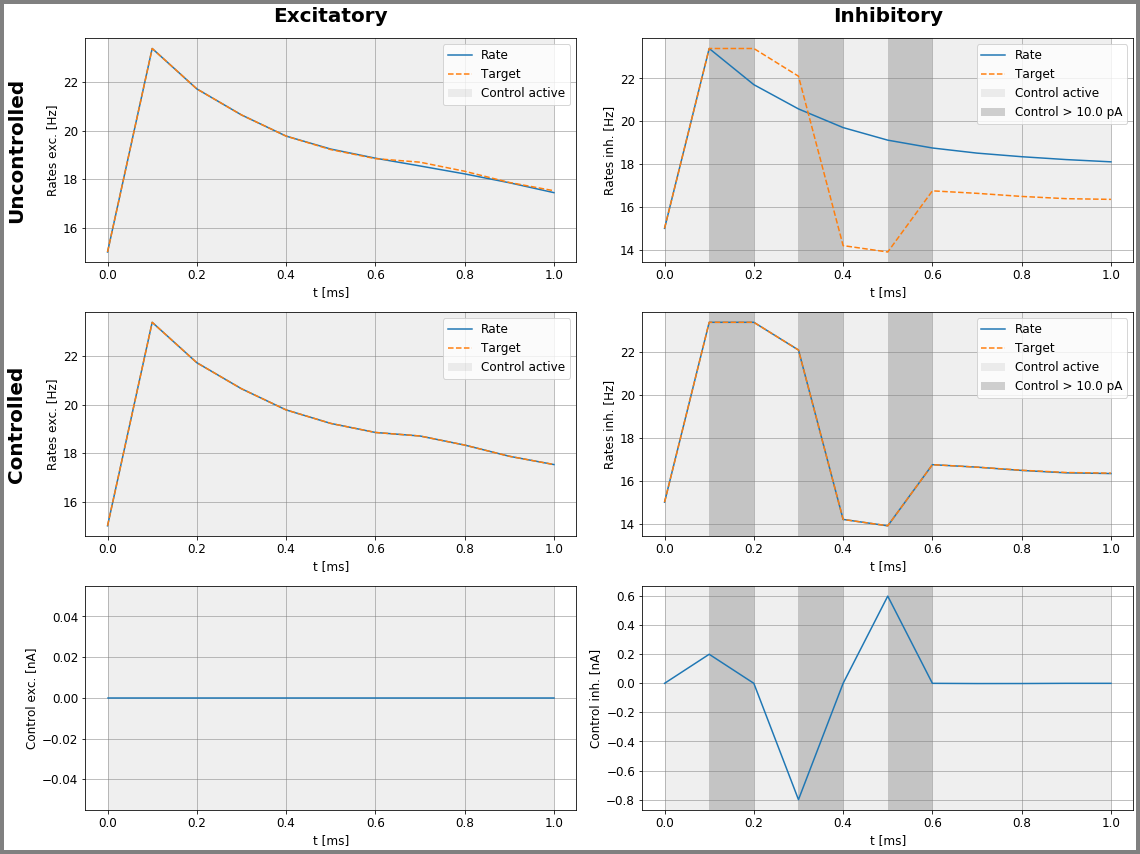

In [120]:
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_inh.pdf')

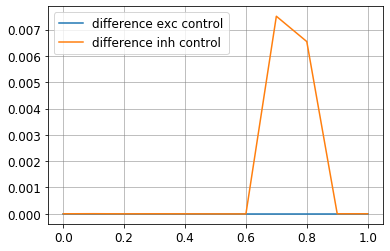

runtime =  5.601444600000832


In [122]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

print("runtime = ", runtime[239])

#plt.plot(aln.t, grad[0,1,:])
#plt.show()

### For excitatory control input only

max delay =  0


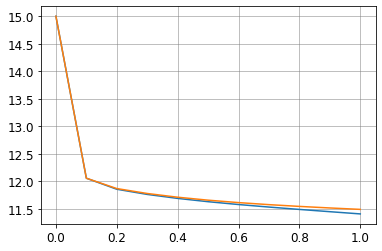

In [118]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

[15.         12.05495703 11.94719066 11.85141667 11.40646584 11.35078578
 11.57176864 11.52563407 11.48229243 11.44079323 11.40001835]
[15.         12.05495703 11.86700691 11.7773948  11.70963055 11.65554961
 11.61175332 11.57473782 11.5422076  11.51343337 11.48731866]


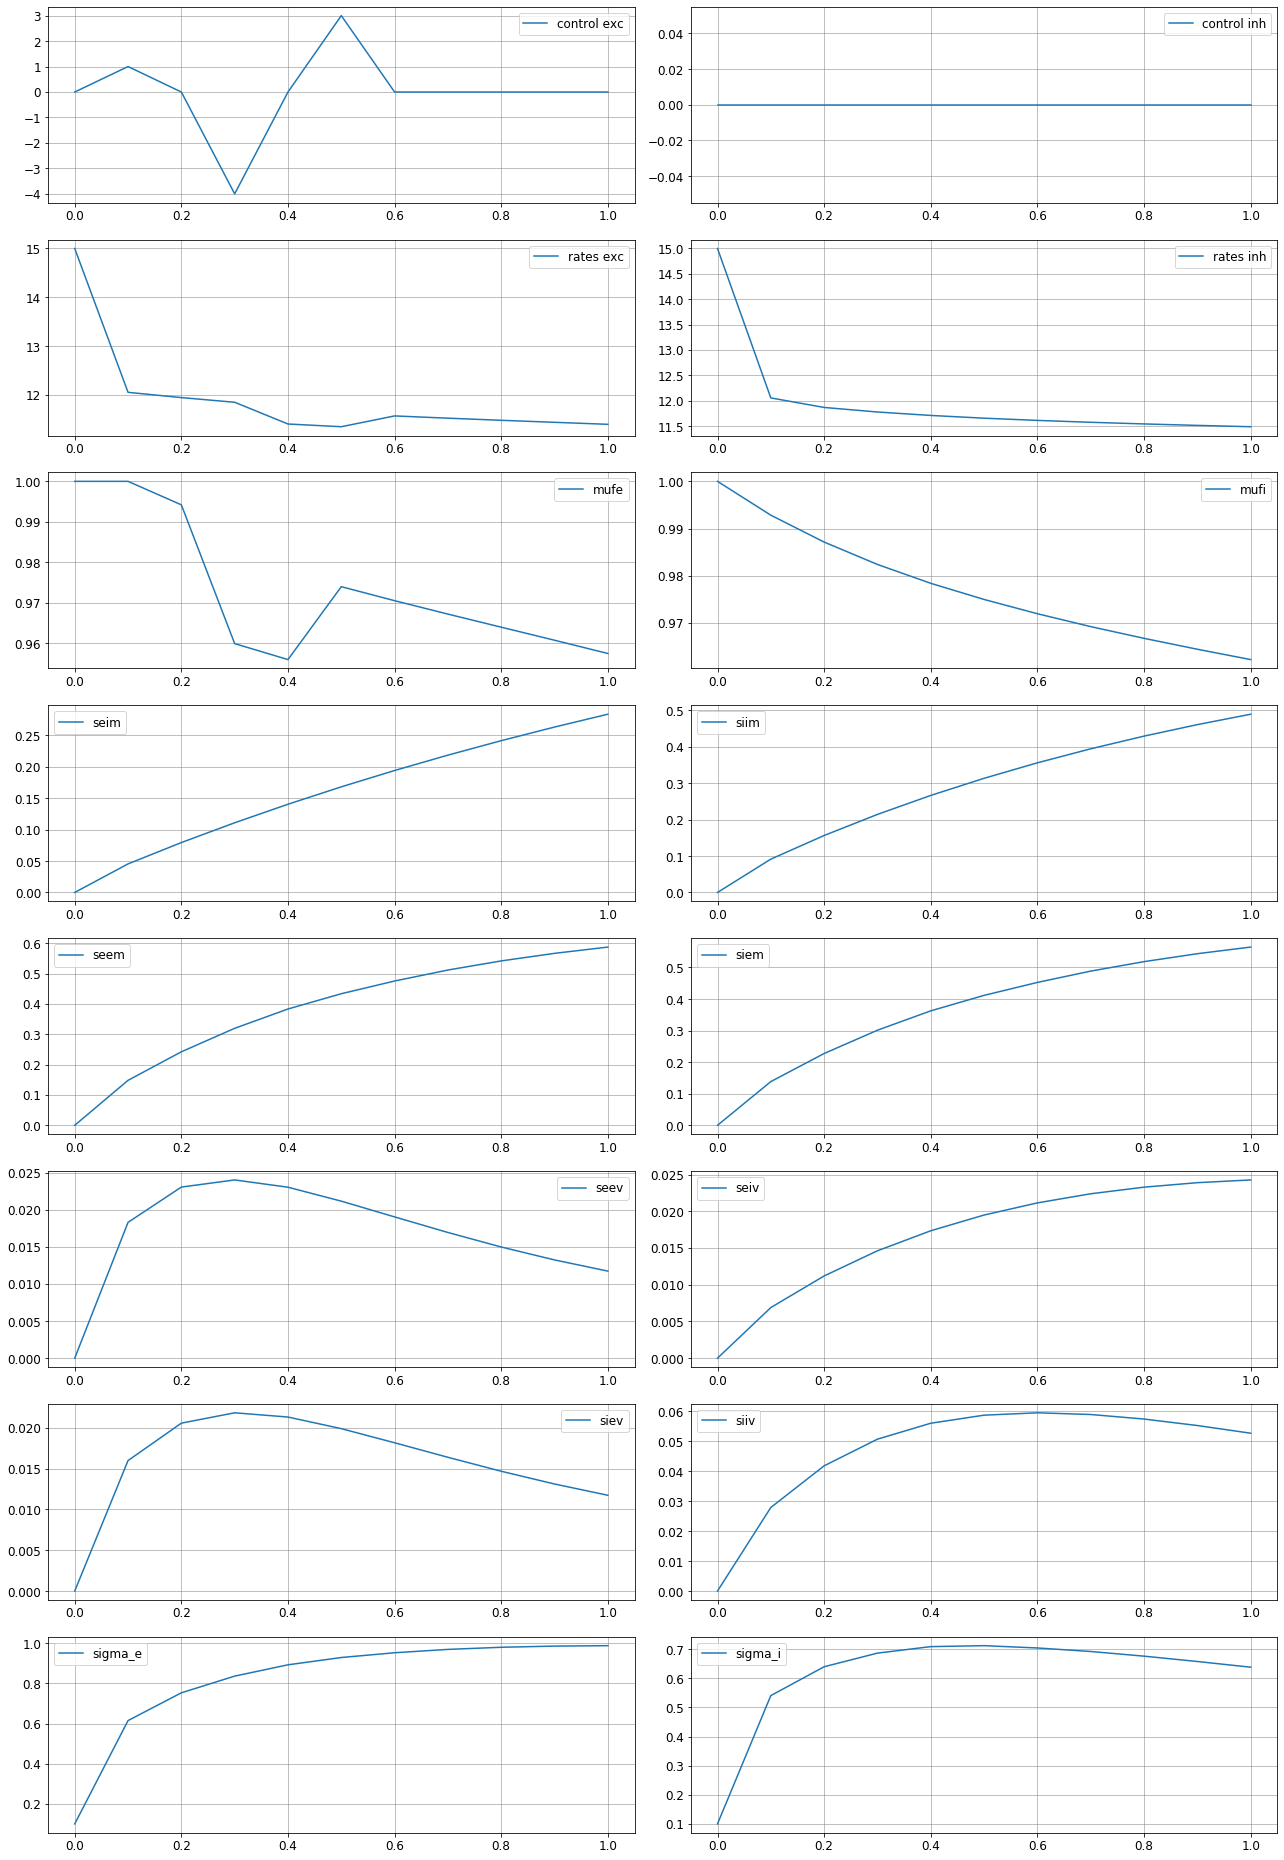

In [120]:
dur = 1.
aln.params.duration = dur
aln.params.de = 0.0
aln.params.di = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

#control1[0,0,1] += 100.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

control1 = aln.getZeroControl()
control1[0,0,3] -= 4.
control1[0,0,1] += 1.
control1[0,0,5] += 3.
#control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0)
plt.savefig("exc_control_no_delay.pdf")
rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[15.         12.05495703 11.94957489 11.85275959 11.41168147 11.36592513
 11.59559057 11.55653431 11.51974481 11.48339691 11.44647725]
[15.         12.05495703 11.87003206 11.77919236 11.71447314 11.67136076
 11.6362646  11.60648558 11.58097049 11.55788613 11.53600687]


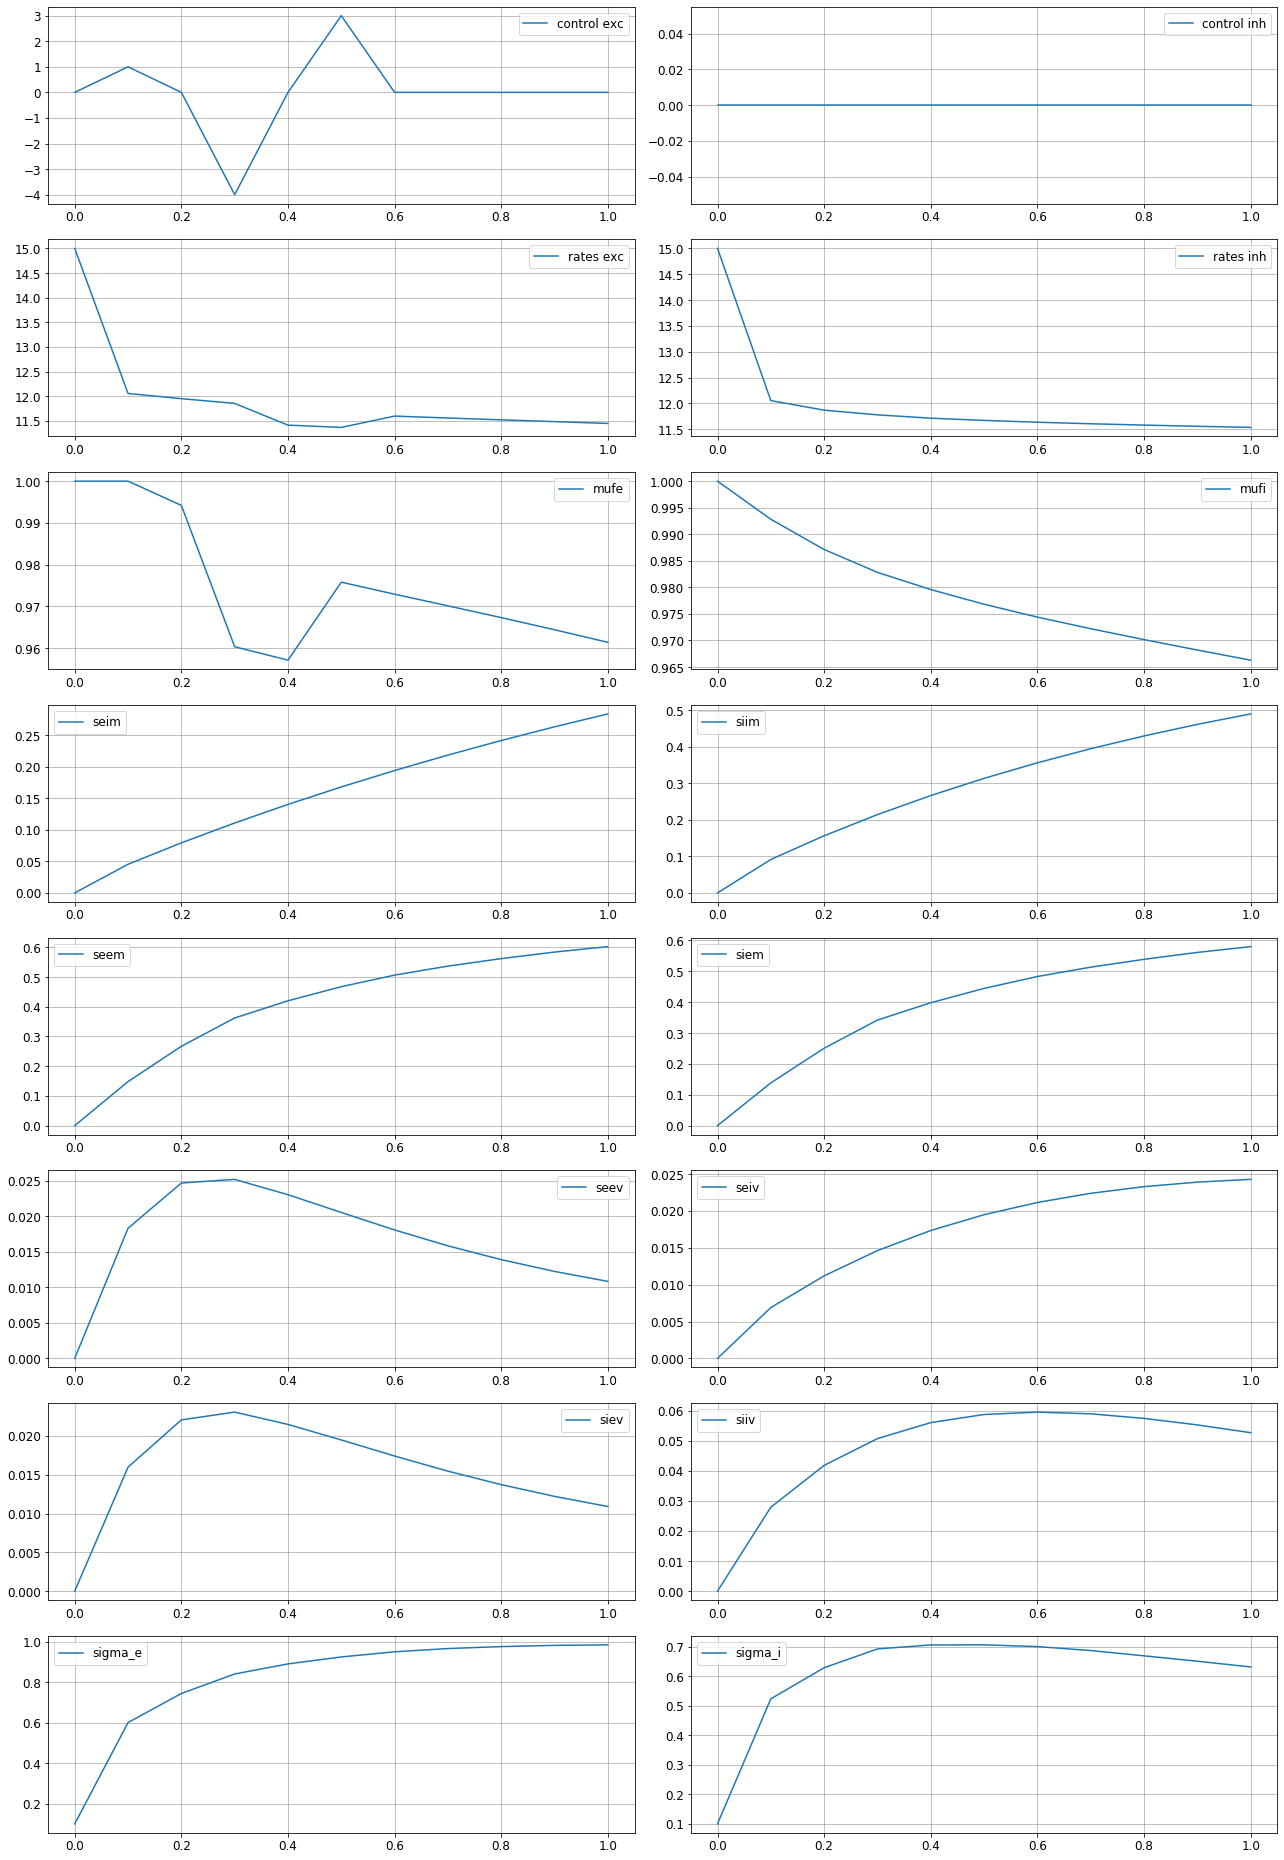

In [121]:
aln.params.de = 0.2
#control1[0,0,5] += 3.
set_init(initvars)
aln.run(control=control1)

rates2 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0)
plt.savefig("exc_control_delay.pdf")

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

(2, 11)
[ 0.          0.         -0.00238423 -0.00134292 -0.00521563 -0.01466974
 -0.02245326 -0.02909848 -0.03537342 -0.0409062  -0.04544696]


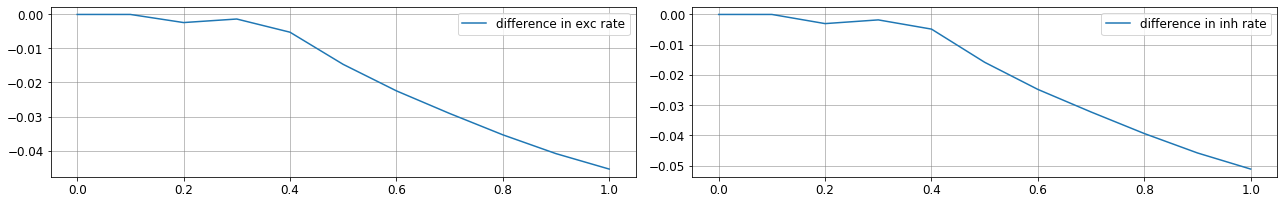

In [103]:
diff = rates1 - rates2
print(diff.shape)
plot_dif(diff)
plt.savefig("diff_exc.pdf")
print(diff[0,:])

In [124]:
max_cntrl = 50. * 5.
start_step = 100000.
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
#control2 = control1
#control2[0,1,:] += 0.1
#control2[0,1,7] += 0.1

max_it = 500
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [1])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control


set cost params
True 2
RUN  0 , total integrated cost =  6.8641965083731135e-09
too small start step, increase to  100000000.0
RUN  1 , total integrated cost =  6.547226046650044e-09
too small start step, increase to  100000000.0
RUN  2 , total integrated cost =  3.749043454955348e-09
too small start step, increase to  100000000.0
RUN  3 , total integrated cost =  2.498174514656965e-09
too small start step, increase to  100000000.0
RUN  4 , total integrated cost =  2.3681539743035048e-09
too small start step, increase to  100000000.0
RUN  5 , total integrated cost =  2.2776361178624847e-09
too small start step, increase to  100000000.0
RUN  6 , total integrated cost =  1.6419576885474901e-09
too small start step, increase to  100000000.0
RUN  7 , total integrated cost =  1.363012893321404e-09
too small start step, increase to  100000000.0
RUN  8 , total integrated cost =  1.3011398455737752e-09
too small start step, increase to  100000000.0
RUN  9 , total integrated cost =  1.249148661

too small start step, increase to  100000000.0
RUN  83 , total integrated cost =  3.80985598245371e-11
too small start step, increase to  100000000.0
RUN  84 , total integrated cost =  3.801081534853458e-11
too small start step, increase to  100000000.0
RUN  85 , total integrated cost =  3.795583188077467e-11
too small start step, increase to  100000000.0
RUN  86 , total integrated cost =  3.755324454191505e-11
too small start step, increase to  100000000.0
RUN  87 , total integrated cost =  3.707799483618935e-11
too small start step, increase to  100000000.0
RUN  88 , total integrated cost =  3.7060786669698756e-11
too small start step, increase to  100000000.0
RUN  89 , total integrated cost =  3.697510801318446e-11
too small start step, increase to  100000000.0
RUN  90 , total integrated cost =  3.692296407447398e-11
too small start step, increase to  100000000.0
RUN  91 , total integrated cost =  3.652795798367814e-11
too small start step, increase to  100000000.0
RUN  92 , total i

too small start step, increase to  100000000.0
RUN  162 , total integrated cost =  7.064280841437474e-12
too small start step, increase to  100000000.0
RUN  163 , total integrated cost =  7.05904540751705e-12
too small start step, increase to  100000000.0
RUN  164 , total integrated cost =  7.058018619282423e-12
too small start step, increase to  100000000.0
RUN  165 , total integrated cost =  7.053531375059817e-12
too small start step, increase to  100000000.0
RUN  166 , total integrated cost =  7.045431838396807e-12
too small start step, increase to  100000000.0
RUN  167 , total integrated cost =  7.044698836829834e-12
too small start step, increase to  100000000.0
RUN  168 , total integrated cost =  7.022108942510118e-12
too small start step, increase to  100000000.0
RUN  169 , total integrated cost =  6.991309835043193e-12
too small start step, increase to  100000000.0
RUN  170 , total integrated cost =  6.990581089027826e-12
too small start step, increase to  100000000.0
RUN  171 

too small start step, increase to  100000000.0
RUN  241 , total integrated cost =  5.85055903438191e-12
too small start step, increase to  100000000.0
RUN  242 , total integrated cost =  5.8456202128136606e-12
too small start step, increase to  100000000.0
RUN  243 , total integrated cost =  5.844862597532867e-12
too small start step, increase to  100000000.0
RUN  244 , total integrated cost =  5.831900657593082e-12
too small start step, increase to  100000000.0
RUN  245 , total integrated cost =  5.813645801611824e-12
too small start step, increase to  100000000.0
RUN  246 , total integrated cost =  5.81291305676554e-12
too small start step, increase to  100000000.0
RUN  247 , total integrated cost =  5.808115043181455e-12
too small start step, increase to  100000000.0
RUN  248 , total integrated cost =  5.805724250320406e-12
too small start step, increase to  100000000.0
RUN  249 , total integrated cost =  5.804467833436051e-12
too small start step, increase to  100000000.0
RUN  250 

too small start step, increase to  100000000.0
RUN  324 , total integrated cost =  2.858080175284069e-12
too small start step, increase to  100000000.0
RUN  325 , total integrated cost =  2.8576463814108e-12
too small start step, increase to  100000000.0
RUN  326 , total integrated cost =  2.853065081579695e-12
too small start step, increase to  100000000.0
RUN  327 , total integrated cost =  2.849724542293739e-12
too small start step, increase to  100000000.0
RUN  328 , total integrated cost =  2.848917613925389e-12
too small start step, increase to  100000000.0
RUN  329 , total integrated cost =  2.847149569224186e-12
too small start step, increase to  100000000.0
RUN  330 , total integrated cost =  2.8466648472016652e-12
too small start step, increase to  100000000.0
RUN  331 , total integrated cost =  2.837628531482747e-12
too small start step, increase to  100000000.0
RUN  332 , total integrated cost =  2.8296740608487556e-12
too small start step, increase to  100000000.0
RUN  333

too small start step, increase to  100000000.0
RUN  403 , total integrated cost =  2.5767507139091005e-12
too small start step, increase to  100000000.0
RUN  404 , total integrated cost =  2.575148045446179e-12
too small start step, increase to  100000000.0
RUN  405 , total integrated cost =  2.574715634675566e-12
too small start step, increase to  100000000.0
RUN  406 , total integrated cost =  2.5665574746529328e-12
too small start step, increase to  100000000.0
RUN  407 , total integrated cost =  2.5594048957035716e-12
too small start step, increase to  100000000.0
RUN  408 , total integrated cost =  2.5580485457761294e-12
too small start step, increase to  100000000.0
RUN  409 , total integrated cost =  2.5557653707747447e-12
too small start step, increase to  100000000.0
RUN  410 , total integrated cost =  2.5553720353194572e-12
too small start step, increase to  100000000.0
RUN  411 , total integrated cost =  2.5451845553813875e-12
too small start step, increase to  100000000.0
R

too small start step, increase to  100000000.0
RUN  482 , total integrated cost =  1.8356838980358448e-13
too small start step, increase to  100000000.0
RUN  483 , total integrated cost =  1.8348557435969284e-13
too small start step, increase to  100000000.0
RUN  484 , total integrated cost =  1.553179806296701e-13
too small start step, increase to  100000000.0
RUN  485 , total integrated cost =  1.505776625374196e-13
too small start step, increase to  100000000.0
RUN  486 , total integrated cost =  1.4968563877955614e-13
too small start step, increase to  100000000.0
RUN  487 , total integrated cost =  1.4899423544605806e-13
too small start step, increase to  100000000.0
RUN  488 , total integrated cost =  1.489188819629249e-13
too small start step, increase to  100000000.0
RUN  489 , total integrated cost =  1.4879242056512214e-13
too small start step, increase to  100000000.0
RUN  490 , total integrated cost =  1.487621605665953e-13
too small start step, increase to  100000000.0
RUN

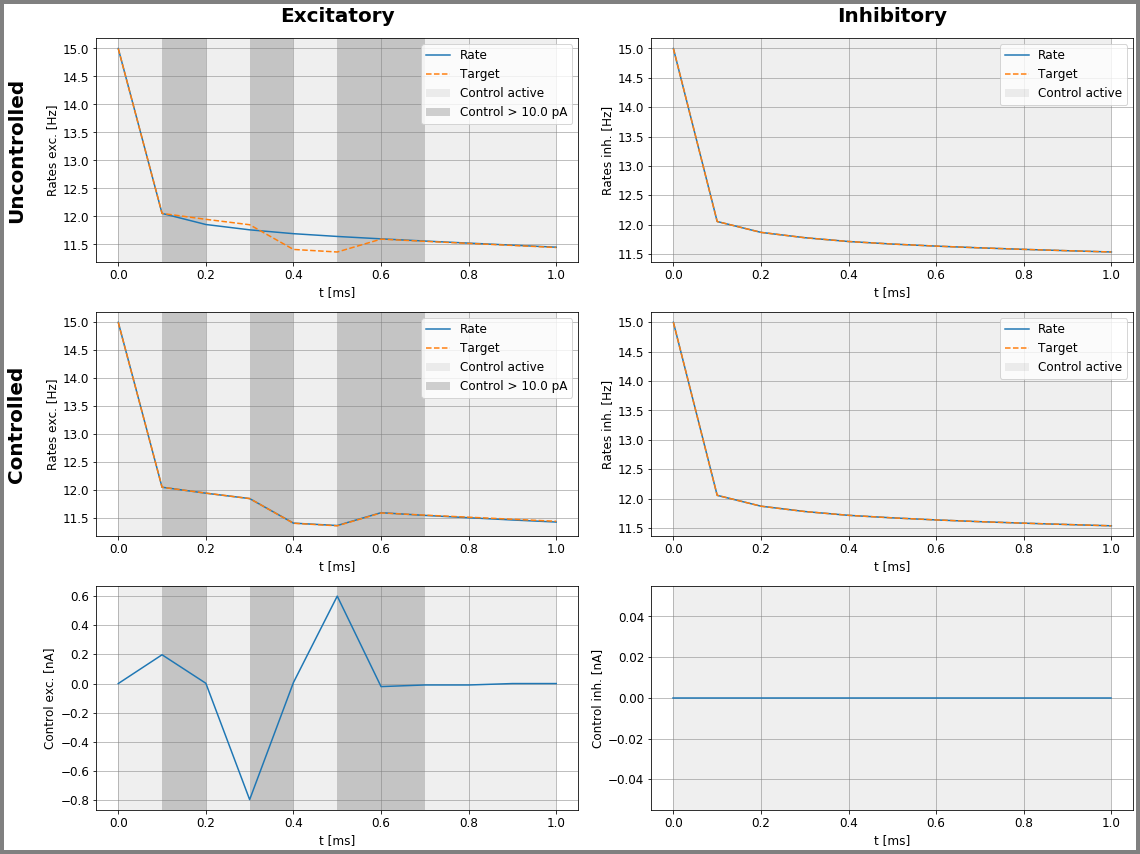

In [125]:
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_exc.pdf')

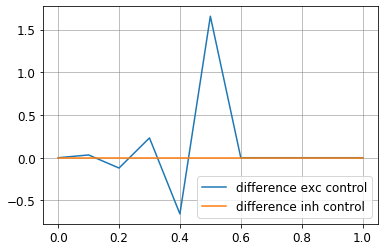

runtime =  13.483455000000049


In [43]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

print("runtime = ", runtime[587])